In [ ]:
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

print(">> Installing dependencies (1-2 min)...")
pip_install(
    "transformers==4.57.1",
    "Pillow",
    "matplotlib",
    "einops",
    "addict",
    "easydict",
    "pymupdf",
    "psutil",
    "accelerate",
)
print(">> Done.")

import os
import torch
from transformers import AutoModel, AutoTokenizer

assert torch.cuda.is_available(), (
    "No GPU detected! In Colab: Runtime -> Change runtime type -> GPU."
)
gpu_name = torch.cuda.get_device_name(0)
print(f">> GPU: {gpu_name}")

use_bf16 = torch.cuda.is_bf16_supported()
DTYPE = torch.bfloat16 if use_bf16 else torch.float16
print(f">> Using dtype: {DTYPE}")

MODEL_NAME = "baidu/Unlimited-OCR"

print(">> Downloading model (~6 GB for 3B params in BF16). First run takes a while...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModel.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    use_safetensors=True,
    torch_dtype=DTYPE,
)
model = model.eval().cuda()
print(">> Model loaded and moved to GPU.")

In [ ]:
from PIL import Image, ImageDraw, ImageFont
import textwrap

os.makedirs("inputs", exist_ok=True)
os.makedirs("outputs/single_gundam", exist_ok=True)
os.makedirs("outputs/single_base", exist_ok=True)
os.makedirs("outputs/multi_page", exist_ok=True)

def load_font(size):
    for path in [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
    ]:
        if os.path.exists(path):
            return ImageFont.truetype(path, size)
    return ImageFont.load_default()

def make_sample_page(path, page_no):
    W, H = 1240, 1754
    img = Image.new("RGB", (W, H), "white")
    d = ImageDraw.Draw(img)
    title_f, head_f, body_f = load_font(48), load_font(34), load_font(26)

    d.text((80, 70), f"Quarterly Operations Report — Page {page_no}",
           fill="black", font=title_f)
    d.line([(80, 145), (W - 80, 145)], fill="black", width=3)

    body = (
        "This document demonstrates Unlimited-OCR's one-shot long-horizon "
        "parsing. The model reads an entire page — headings, paragraphs, "
        "and tables — and emits structured text in a single decoding pass. "
        "Unlike classic OCR pipelines, no separate layout-analysis stage "
        "is required."
    )
    y = 190
    for line in textwrap.wrap(body, width=72):
        d.text((80, y), line, fill="black", font=body_f)
        y += 40

    y += 30
    d.text((80, y), f"Table {page_no}: Regional Revenue (USD, millions)",
           fill="black", font=head_f)
    y += 60
    rows = [
        ["Region",  "Q1",   "Q2",   "Q3"],
        ["North",   "12.4", "13.1", "15.0"],
        ["South",   "9.8",  "10.2", "11.7"],
        ["East",    "14.3", "13.9", "16.2"],
        ["West",    "11.1", "12.5", "12.9"],
    ]
    col_w, row_h, x0 = 260, 56, 80
    for r, row in enumerate(rows):
        for c, cell in enumerate(row):
            x = x0 + c * col_w
            d.rectangle([x, y, x + col_w, y + row_h], outline="black", width=2)
            d.text((x + 14, y + 12), cell, fill="black", font=body_f)
        y += row_h

    y += 50
    footer = (
        f"Note {page_no}: Figures are illustrative. Multi-page mode stitches "
        "context across pages, so cross-page references remain coherent."
    )
    for line in textwrap.wrap(footer, width=72):
        d.text((80, y), line, fill="black", font=body_f)
        y += 40

    img.save(path)
    return path

IMAGE_PATH = make_sample_page("inputs/sample_page_1.png", 1)
PAGE_2     = make_sample_page("inputs/sample_page_2.png", 2)
PAGE_3     = make_sample_page("inputs/sample_page_3.png", 3)
print(f">> Sample pages written: {IMAGE_PATH}, {PAGE_2}, {PAGE_3}")

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 8))
plt.imshow(Image.open(IMAGE_PATH))
plt.axis("off")
plt.title("Input document (page 1)")
plt.show()

In [ ]:
print("\n" + "=" * 76)
print("STEP 4: Single image — GUNDAM mode (tiled, high detail)")
print("=" * 76)

model.infer(
    tokenizer,
    prompt="<image>document parsing.",
    image_file=IMAGE_PATH,
    output_path="outputs/single_gundam",
    base_size=1024,
    image_size=640,
    crop_mode=True,
    max_length=32768,
    no_repeat_ngram_size=35,
    ngram_window=128,
    save_results=True,
)

In [ ]:
print("\n" + "=" * 76)
print("STEP 5: Single image — BASE mode (single view, faster)")
print("=" * 76)

model.infer(
    tokenizer,
    prompt="<image>document parsing.",
    image_file=IMAGE_PATH,
    output_path="outputs/single_base",
    base_size=1024,
    image_size=1024,
    crop_mode=False,
    max_length=32768,
    no_repeat_ngram_size=35,
    ngram_window=128,
    save_results=True,
)

In [ ]:
print("\n" + "=" * 76)
print("STEP 6: Multi-page / PDF parsing")
print("=" * 76)

import tempfile
import fitz

def pdf_to_images(pdf_path, dpi=300):
    """Rasterize every PDF page to a PNG; return the list of image paths."""
    doc = fitz.open(pdf_path)
    tmp_dir = tempfile.mkdtemp(prefix="pdf_ocr_")
    mat = fitz.Matrix(dpi / 72, dpi / 72)
    paths = []
    for i, page in enumerate(doc):
        out = os.path.join(tmp_dir, f"page_{i + 1:04d}.png")
        page.get_pixmap(matrix=mat).save(out)
        paths.append(out)
    doc.close()
    return paths

SAMPLE_PDF = "inputs/sample_doc.pdf"
pdf = fitz.open()
for p in [IMAGE_PATH, PAGE_2, PAGE_3]:
    img_doc = fitz.open(p)
    rect = img_doc[0].rect
    pdf_bytes = img_doc.convert_to_pdf()
    img_pdf = fitz.open("pdf", pdf_bytes)
    page = pdf.new_page(width=rect.width, height=rect.height)
    page.show_pdf_page(rect, img_pdf, 0)
pdf.save(SAMPLE_PDF)
pdf.close()
print(f">> Built sample PDF: {SAMPLE_PDF}")

page_images = pdf_to_images(SAMPLE_PDF, dpi=300)
print(f">> Rasterized {len(page_images)} pages")

model.infer_multi(
    tokenizer,
    prompt="<image>Multi page parsing.",
    image_files=page_images,
    output_path="outputs/multi_page",
    image_size=1024,
    max_length=32768,
    no_repeat_ngram_size=35,
    ngram_window=1024,
    save_results=True,
)

>> Installing dependencies (1-2 min)...
>> Done.
>> GPU: Tesla T4
>> Using dtype: torch.bfloat16
>> Downloading model (~6 GB for 3B params in BF16). First run takes a while...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/801 [00:00<?, ?B/s]

...

A new version of the following files was downloaded from https://huggingface.co/baidu/Unlimited-OCR:
- conversation.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/baidu/Unlimited-OCR:
- modeling_unlimitedocr.py
- modeling_deepseekv2.py
- deepencoder.py
- conversation.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-000001.safetensors:   0%|          | 0.00/6.67G [00:00<?, ?B/s]

Some weights of UnlimitedOCRForCausalLM were not initialized from the model checkpoint at baidu/Unlimited-OCR and are newly initialized: ['model.vision_model.embeddings.position_ids']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


>> Model loaded and moved to GPU.
>> Sample pages written: inputs/sample_page_1.png, inputs/sample_page_2.png, inputs/sample_page_3.png


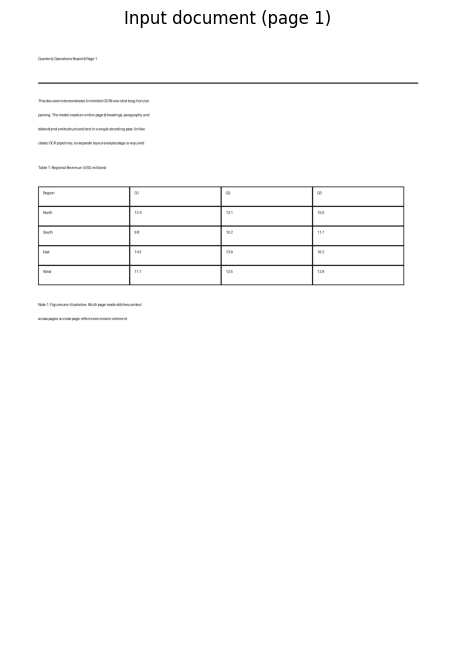


STEP 4: Single image — GUNDAM mode (tiled, high detail)


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


<|det|>header [62, 39, 201, 49]<|/det|>Quarterly Operations Report Page 1
<|det|>text [62, 107, 321, 117]<|/det|>This document demonstrates Unlimited OCR's one-shot long-horizon
<|det|>text [62, 130, 321, 140]<|/det|>parsing. The model reads an entire page of headings, paragraphs, and
<|det|>text [62, 153, 310, 163]<|/det|>tables and emits structured text in a single decoding pass. Unlike
<|det|>text [62, 176, 310, 186]<|/det|>classic OCR pipelines, no separate layout-analysis stage is required.
<|det|>text [62, 216, 222, 226]<|/det|>Table 1: Regional Revenue (USD, millions)
<|det|>table [62, 248, 907, 412]<|/det|><table><tr><td>Region</td><td>Q1</td><td>Q2</td><td>Q3</td></tr><tr><td>North</td><td>12.4</td><td>13.1</td><td>15.0</td></tr><tr><td>South</td><td>9.8</td><td>10.2</td><td>11.7</td></tr><tr><td>East</td><td>14.3</td><td>13.9</td><td>16.2</td></tr><tr><td>West</td><td>11.1</td><td>12.5</td><td>12.9</td></tr></table>
<|det|>text [62, 438, 304, 448]<|/det|>Note 1: Figures are i

image: 0it [00:00, ?it/s]
other: 100%|██████████| 9/9 [00:00<00:00, 57896.83it/s]


STEP 5: Single image — BASE mode (single view, faster)


...

<PAGE><|det|>header [63, 39, 201, 49]<|/det|>Quarterly Operations Report& Page 1
<|det|>text [62, 106, 321, 116]<|/det|>This document demonstrates Unlimited OCR for each long horizontal line.
<|det|>text [62, 129, 321, 139]<|/det|>parsing. The model measures entire page headings, paragraphs, and
<|det|>text [62, 152, 312, 162]<|/det|>tablestand emittance out text in a single decoding pass. Unlike
<|det|>text [62, 175, 310, 185]<|/det|>classic CSS1 pipelines, no separate layout analysis step is required.
<|det|>text [62, 216, 223, 226]<|/det|>Table 1: Regional Revenue (US$2 million)
<|det|>table [62, 248, 905, 412]<|/det|><table><tr><td>Region</td><td>Q1</td><td>Q2</td><td>Q3</td></tr><tr><td>North</td><td>12.4</td><td>13.1</td><td>16.0</td></tr><tr><td>South</td><td>9.8</td><td>10.2</td><td>11.7</td></tr><tr><td>East</td><td>14.3</td><td>13.9</td><td>16.2</td></tr><tr><td>West</td><td>11.1</td><td>12.5</td><td>12.8</td></tr></table>
<|det|>text [62, 438, 304, 448]<|/det|>Note 1: Figure

image_page_0: 0it [00:00, ?it/s]
other_page_0: 100%|██████████| 9/9 [00:00<00:00, 68884.55it/s]
image_page_1: 0it [00:00, ?it/s]
other_page_1: 100%|██████████| 9/9 [00:00<00:00, 88197.98it/s]


closing parenthesis ']' does not match opening parenthesis '(' (<string>, line 1)


image_page_2: 0it [00:00, ?it/s]
other_page_2: 100%|██████████| 9/9 [00:00<00:00, 88612.06it/s]


STEP 7: Saved outputs

--- outputs/single_gundam ---
  outputs/single_gundam/result.md  (788 bytes)
  ------------------------------------------------------------
  | Quarterly Operations Report Page 1
  | This document demonstrates Unlimited OCR's one-shot long-horizon
  | parsing. The model reads an entire page of headings, paragraphs, and
  | tables and emits structured text in a single decoding pass. Unlike
  | classic OCR pipelines, no separate layout-analysis stage is required.
  | Table 1: Regional Revenue (USD, millions)
  | <table><tr><td>Region</td><td>Q1</td><td>Q2</td><td>Q3</td></tr><tr><td>North</td><td>12.4</td><td>13.1</td><td>15.0</td></tr><tr><td>South</td><td>9.8</td><td>10.2</td><td>11.7</td></tr><tr><td>East</td><td>14.3</td><td>13.9</td><td>16.2</td></tr><tr><td>West</td><td>11.1</td><td>12.5</td><td>12.9</td></tr></table>
  | Note 1: Figures are illustrative. Multi-page mode stitches context
  | across pages, so cross-page references remain coherent.
  ---------

In [1]:
print("\n" + "=" * 76)
print("STEP 7: Saved outputs")
print("=" * 76)

TEXT_EXTS = {".txt", ".md", ".mmd", ".json"}

def show_outputs(root):
    print(f"\n--- {root} ---")
    if not os.path.isdir(root):
        print("  (no output directory found)")
        return
    for dirpath, _, files in os.walk(root):
        for fn in sorted(files):
            fp = os.path.join(dirpath, fn)
            size = os.path.getsize(fp)
            print(f"  {fp}  ({size:,} bytes)")
            if os.path.splitext(fn)[1].lower() in TEXT_EXTS:
                with open(fp, "r", encoding="utf-8", errors="replace") as f:
                    content = f.read()
                preview = content[:1500]
                print("  " + "-" * 60)
                print("\n".join("  | " + ln for ln in preview.splitlines()))
                if len(content) > 1500:
                    print(f"  | ... [{len(content) - 1500:,} more chars]")
                print("  " + "-" * 60)

for out_dir in ["outputs/single_gundam", "outputs/single_base", "outputs/multi_page"]:
    show_outputs(out_dir)

print("""
============================================================================
 DONE — CHEAT SHEET
============================================================================
 Single image, dense/small text .... infer(), gundam (640 + crop_mode=True)
 Single image, clean print ......... infer(), base   (1024, crop_mode=False)
 Multi-page or PDF ................. infer_multi(), image_size=1024,
                                     ngram_window=1024
 Long documents .................... keep max_length=32768 and the
                                     no_repeat_ngram settings — they prevent
                                     degeneration on long outputs.
 Your own files .................... upload via Colab sidebar, point
                                     image_file / pdf_to_images() at them.
============================================================================
""")